In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [2]:
df_applications = pd.read_csv('./data/cleaned_data/applications.csv')
df_voyage_schedule = pd.read_csv('./data/cleaned_data/voyage_schedule.csv')

In [4]:
# Examine the shape and data types of both DataFrames
print("df_applications shape:", df_applications.shape)
print("df_applications data types:\n", df_applications.dtypes)
print("\ndf_voyage_schedule shape:", df_voyage_schedule.shape)
print("df_voyage_schedule data types:\n", df_voyage_schedule.dtypes)

# Inspect the 'voyage(from voyage signup)' column in df_applications
print("\nUnique values in voyage_from_voyage_signups':", df_applications['voyage_from_voyage_signups'].unique())
print("Value counts for 'voyage_from_voyage_signups)':\n", df_applications['voyage_from_voyage_signups'].value_counts())
print("Missing values in 'voyage_from_voyage_signups':", df_applications['voyage_from_voyage_signups'].isnull().sum())

# Identify the relevant columns in df_voyage_schedule
print("\nRelevant columns in df_voyage_schedule (Voyage numbers and dates): 'Name', 'Start Date', 'End Date'")

# Analyze the relationship between the voyage numbers in both DataFrames
common_voyages = set(df_applications['voyage_from_voyage_signups'].dropna()).intersection(set(df_voyage_schedule['Name']))
print("\nCommon voyage numbers between df_applications and df_voyage_schedule:", common_voyages)

df_applications shape: (10600, 16)
df_applications data types:
 unique_id                      object
subscription_status            object
subscription_status_dt         object
voyage_role                    object
gender                         object
goal                           object
source                         object
country_name_from_country      object
voyage_from_voyage_signups     object
application_age_in_days       float64
application_day_of_week        object
day_of_week_no                float64
no_voyages_started            float64
application_date               object
updated_voyage_number          object
updated_voyage_start_date      object
dtype: object

df_voyage_schedule shape: (48, 3)
df_voyage_schedule data types:
 Name          object
Start Date    object
End Date      object
dtype: object

Unique values in voyage_from_voyage_signups': [nan 'V??' 'V55' 'V54' 'V53' 'V52' 'V51' 'V50' 'V49' 'V48' 'V47' 'V45'
 'V46' 'V44' 'V43' 'V42' 'V99' 'V41' 'V40' 'V39' 'V3

KeyError: 'voyage_from_voyage_signups)'

In [4]:
# Analyze the distribution of voyage numbers in 'Voyage (from Voyage Signups)'
voyage_counts = df_applications['Voyage (from Voyage Signups)'].value_counts()
print("Voyage number distribution:\n", voyage_counts)

# Check if there are any common voyage numbers between df_applications and df_voyage_schedule
common_voyages = set(df_applications['Voyage (from Voyage Signups)'].dropna()).intersection(set(df_voyage_schedule['Name']))
print("\nCommon voyage numbers between df_applications and df_voyage_schedule:", common_voyages)

# Further exploration of the 'Voyage (from Voyage Signups)' column
# Check for inconsistencies or patterns in the voyage numbers
# For example, look for multiple voyage numbers separated by commas
# Also, analyze the frequency of 'V??' and its potential meaning

Voyage number distribution:
 Voyage (from Voyage Signups)
V45                    151
V43                    130
V44                    111
V40                    106
V41                     99
                      ... 
V??,V??,V53              1
V51,V53,V54              1
V51,V53,V52,V53,V54      1
V51,V51,V53              1
V51,V54                  1
Name: count, Length: 397, dtype: int64

Common voyage numbers between df_applications and df_voyage_schedule: {'V32', 'V42', 'V43', 'V33', 'V54', 'V51', 'V52', 'V48', 'V53', 'V50', 'V47', 'V44', 'V35', 'V37', 'V36', 'V49', 'V46', 'V55', 'V38', 'V34', 'V40', 'V39', 'V41', 'V45'}


In [6]:
# Analyze the 'Voyage (from Voyage Signups)' column for inconsistencies and patterns
# Check for multiple voyage numbers separated by commas
df_applications['voyage_from_voyage_signups'].str.contains(',').sum()

# Analyze the frequency of 'V??' and its potential meaning
print("Frequency of 'V??':", df_applications['voyage_from_voyage_signups'].str.contains('V\?\?').sum())

# Further exploration:
# Analyze the relationship between the voyage numbers and the 'Application Date' column
# Check if there are any specific voyage numbers associated with missing values
# Analyze the 'Voyage Role' and 'Goal' columns in relation to the voyage numbers

Frequency of 'V??': 146


In [8]:
# Analyze the relationship between the voyage numbers in both DataFrames
# Check if there are any common voyage numbers, and if the voyage numbers in df_applications match the voyage numbers in df_voyage_schedule
common_voyages = set(df_applications['voyage_from_voyage_signups'].dropna()).intersection(set(df_voyage_schedule['Name']))
print("Common voyage numbers between df_applications and df_voyage_schedule:", common_voyages)

# Explore the potential meaning of 'V??'
# Check if it's associated with a specific application date or other attributes
df_v_question_mark = df_applications[df_applications['voyage_from_voyage_signups'].str.contains('V\?\?', na=False)]
print("\nRows with 'V??':\n", df_v_question_mark.head())

# Check if 'V??' is related to the application date
print("\nApplication dates associated with 'V??':\n", df_v_question_mark['application_date'].value_counts())

Common voyage numbers between df_applications and df_voyage_schedule: {'V32', 'V54', 'V53', 'V48', 'V51', 'V43', 'V36', 'V47', 'V41', 'V33', 'V35', 'V39', 'V50', 'V34', 'V46', 'V40', 'V55', 'V42', 'V38', 'V52', 'V44', 'V49', 'V45', 'V37'}

Rows with 'V??':
                             unique_id subscription_status  \
24   7be16909aa5092c16b8aca8e2b670969              Active   
27   2edcefff8314a00296bf4adc1aa25ed0              Active   
30   9f4e32681a0ab7d9e534a276d13c8c65              Active   
55   0b79c89ebb33b3b73e8818a7340a516b              Active   
119  020d590f46116b3351b0624996b4ac43              Active   

    subscription_status_dt   voyage_role  gender                       goal  \
24               2/26/2025     Developer  FEMALE  NETWORK WITH SHARED GOALS   
27               2/25/2025     Developer  FEMALE            GAIN EXPERIENCE   
30               2/25/2025     Developer    MALE            GAIN EXPERIENCE   
55               2/23/2025  Scrum Master    MALE           

In [9]:
df_expanded_applications = pd.DataFrame()

for index, row in df_applications.iterrows():
  voyage_str = row['voyage_from_voyage_signups']
  if isinstance(voyage_str, str) and ',' in voyage_str:
    voyages = [v.strip() for v in voyage_str.split(',')]
    for voyage in voyages:
      new_row = row.copy()
      new_row['voyage_from_voyage_signups'] = voyage
      df_expanded_applications = pd.concat([df_expanded_applications, pd.DataFrame([new_row])], ignore_index=True)
  else:
    df_expanded_applications = pd.concat([df_expanded_applications, pd.DataFrame([row])], ignore_index=True)

In [13]:
voyage_date_dict = {}
for index, row in df_voyage_schedule.iterrows():
  voyage_number = row['Name']
  start_date = row['Start Date']
  if pd.notna(start_date):
    voyage_date_dict[voyage_number] = start_date

In [14]:
# Convert date fields to datetime
df_expanded_applications['application_date'] = pd.to_datetime(df_applications['application_date'], errors='coerce')
df_voyage_schedule['Start Date'] = pd.to_datetime(df_voyage_schedule['Start Date'], errors='coerce')

# Prepare target columns
df_expanded_applications['updated_voyage_number'] = None
df_expanded_applications['updated_voyage_number'] = None

# Sort voyages by Start Date
df_voyage_schedule = df_voyage_schedule.sort_values('Start Date')

# Function to get the next voyage
def find_next_voyage(application_date):
    if pd.isna(application_date):
        return None, None
    future_voyages = df_voyage_schedule[df_voyage_schedule['Start Date'] > application_date]
    if future_voyages.empty:
        return None, None
    next_voyage = future_voyages.iloc[1]  # Pick the first available voyage
    return next_voyage['Name'], next_voyage['Start Date'] 

# Apply update for 'V??'
mask = df_expanded_applications['voyage_from_voyage_signups'] == 'V??'
for idx in df_expanded_applications[mask].index:
    app_date = df_expanded_applications.at[idx, 'application_date']
    name, start_date = find_next_voyage(app_date)
    df_expanded_applications.at[idx, 'updated_voyage_number'] = name
    df_expanded_applications.at[idx, 'updated_voyage_start_date'] = start_date

# Regex to match 'V##' where ## is numeric (2 or 3 digits)
regex_mask = df_expanded_applications['voyage_from_voyage_signups'].fillna('').str.match(r'^V\d{2,3}$')

# Apply update for 'V##'
for idx in df_expanded_applications[regex_mask].index:
    voyage_name = df_expanded_applications.at[idx, 'voyage_from_voyage_signups']
    voyage_row = df_voyage_schedule[df_voyage_schedule['Name'] == voyage_name]
    if not voyage_row.empty:
        df_expanded_applications.at[idx, 'updated_voyage_start_date'] = voyage_row.iloc[0]['Start Date']
        df_expanded_applications.at[idx, 'updated_voyage_number'] = voyage_name


In [15]:
df_expanded_applications['updated_voyage_number'].fillna('')
df_expanded_applications['updated_voyage_start_date'].fillna('')

0         
1         
2         
3         
4         
        ..
10595     
10596     
10597     
10598     
10599     
Name: updated_voyage_start_date, Length: 10600, dtype: object

In [17]:
# Prepare data for weekly trends by 'Application Day-of-Week'
day_order = ['0. Saturday', '1. Sunday', '2. Monday', '3. Tuesday', '4. Wednesday', '5. Thursday', '6. Friday']

# Count number of applications per day of week
weekly_counts = df_expanded_applications['application_day_of_Week'].value_counts().reindex(day_order)

# Plot
plt.figure(figsize=(10, 6))
weekly_counts.plot(kind='bar')
plt.title("Applications by Day of the Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Applications")
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(True)
plt.show()

KeyError: 'application_day_of_Week'

<Figure size 2000x1500 with 0 Axes>

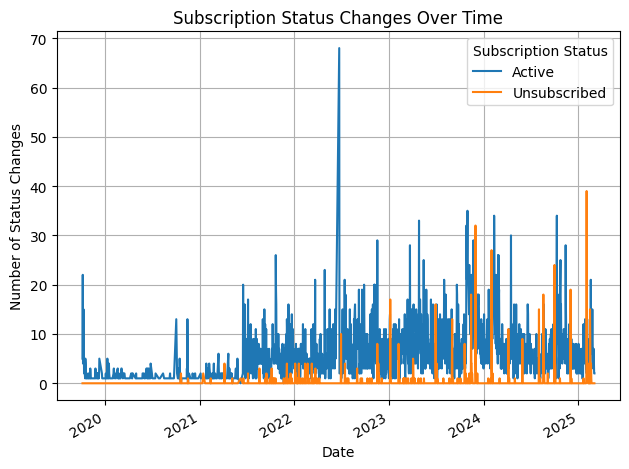

In [86]:
# Convert 'Subscription Status DT' to datetime
df_expanded_applications['Subscription Status DT'] = pd.to_datetime(df_expanded_applications['Subscription Status DT'], errors='coerce')

# Count subscription status changes over time
subscription_time_series = (
    df_expanded_applications.groupby(['Subscription Status DT', 'Subscription Status'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Plot
plt.figure(figsize=(20, 15))
subscription_time_series.plot()
plt.title("Subscription Status Changes Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Status Changes")
plt.grid(True)
plt.tight_layout()
plt.show()

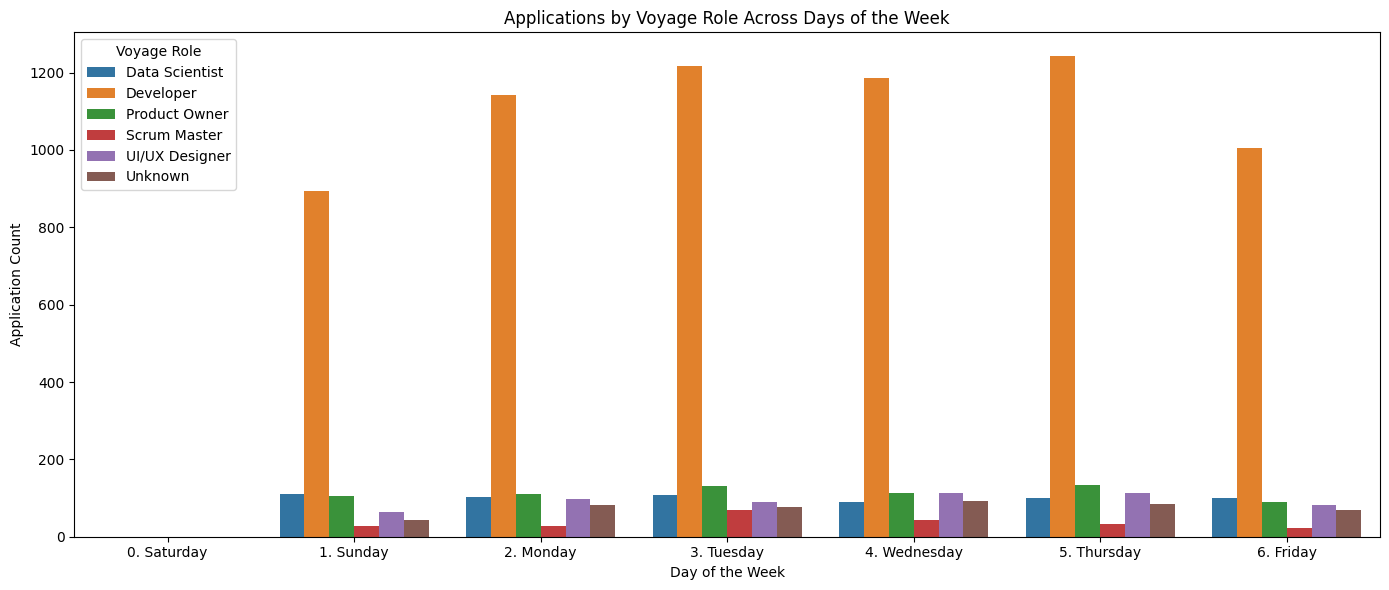

In [87]:
import seaborn as sns
# Filter relevant columns
role_goal_df = df_expanded_applications[['Voyage Role', 'Goal', 'Application Day-of-Week']].dropna()

# Count of applications by Role and Day of Week
role_day_counts = (
    role_goal_df.groupby(['Application Day-of-Week', 'Voyage Role'])
    .size()
    .reset_index(name='Count')
)

# Sort days
role_day_counts['Application Day-of-Week'] = pd.Categorical(
    role_day_counts['Application Day-of-Week'],
    categories=['0. Saturday', '1. Sunday', '2. Monday', '3. Tuesday', '4. Wednesday', '5. Thursday', '6. Friday'],
    ordered=True
)

# Plot
plt.figure(figsize=(14, 6))
sns.barplot(
    data=role_day_counts,
    x='Application Day-of-Week',
    y='Count',
    hue='Voyage Role'
)
plt.title("Applications by Voyage Role Across Days of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Application Count")
plt.legend(title='Voyage Role')
plt.tight_layout()
plt.show()

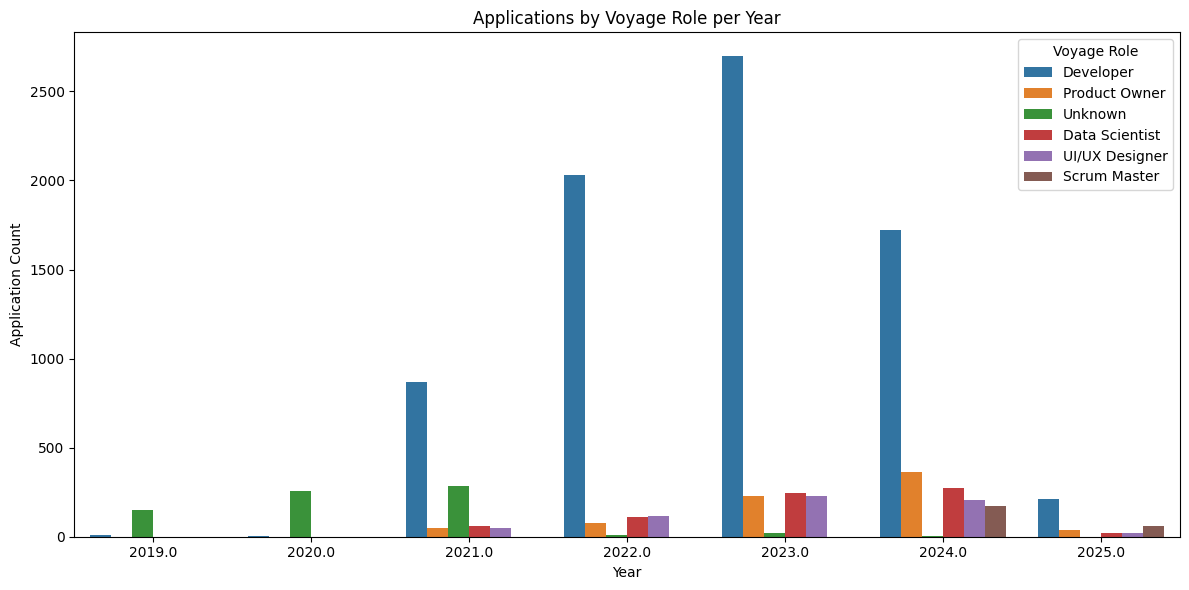

In [88]:
# Convert 'Timestamp' to datetime
df_expanded_applications['Timestamp'] = pd.to_datetime(df_expanded_applications['Timestamp'], errors='coerce')

# Extract year from timestamp
df_expanded_applications['Application Year'] = df_expanded_applications['Timestamp'].dt.year

# Group by year and Voyage Role
year_role_counts = (
    df_expanded_applications.groupby(['Application Year', 'Voyage Role'])
    .size()
    .reset_index(name='Count')
    .dropna()
)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=year_role_counts,
    x='Application Year',
    y='Count',
    hue='Voyage Role'
)
plt.title("Applications by Voyage Role per Year")
plt.xlabel("Year")
plt.ylabel("Application Count")
plt.legend(title='Voyage Role')
plt.tight_layout()
plt.show()

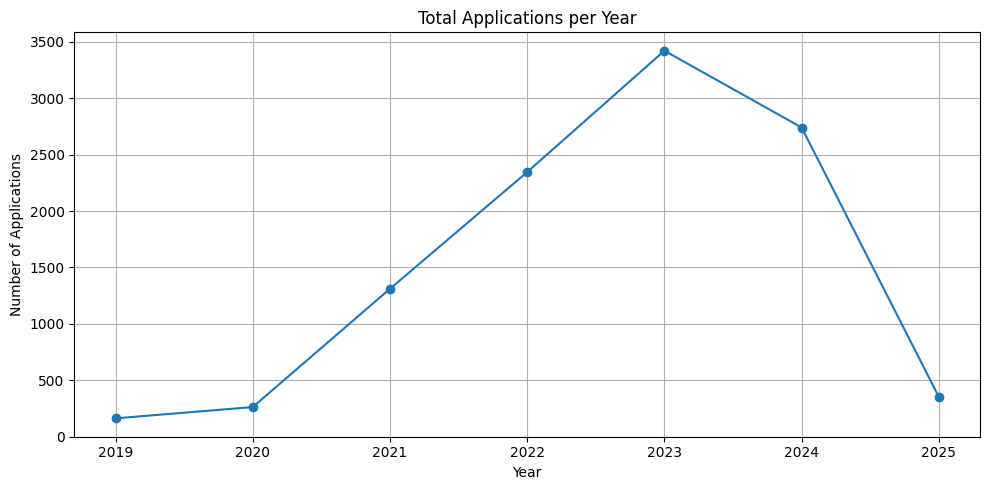

In [89]:
yearly_trend = df_expanded_applications['Application Year'].value_counts().sort_index()

# Plot line trend
plt.figure(figsize=(10, 5))
plt.plot(yearly_trend.index, yearly_trend.values, marker='o')
plt.title("Total Applications per Year")
plt.xlabel("Year")
plt.ylabel("Number of Applications")
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

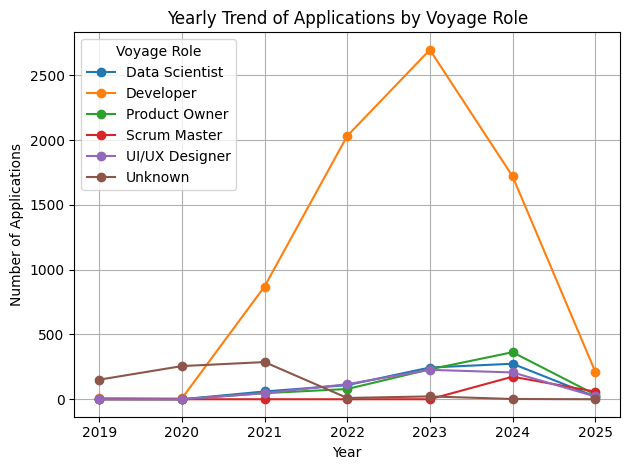

<Figure size 1400x600 with 0 Axes>

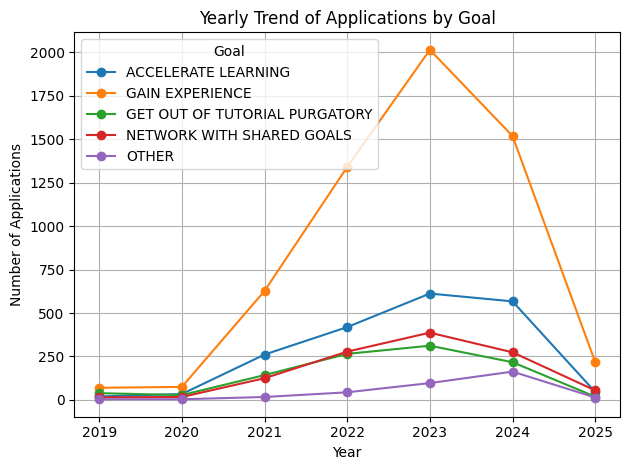

In [90]:
# Group by year and voyage role
yearly_role_trend = (
    df_expanded_applications.groupby(['Application Year', 'Voyage Role'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Group by year and goal
yearly_goal_trend = (
    df_expanded_applications.groupby(['Application Year', 'Goal'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Plot role trend
plt.figure(figsize=(12, 5))
yearly_role_trend.plot(marker='o')
plt.title("Yearly Trend of Applications by Voyage Role")
plt.xlabel("Year")
plt.ylabel("Number of Applications")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot goal trend
plt.figure(figsize=(14, 6))
yearly_goal_trend.plot(marker='o')
plt.title("Yearly Trend of Applications by Goal")
plt.xlabel("Year")
plt.ylabel("Number of Applications")
plt.grid(True)
plt.tight_layout()
plt.show()

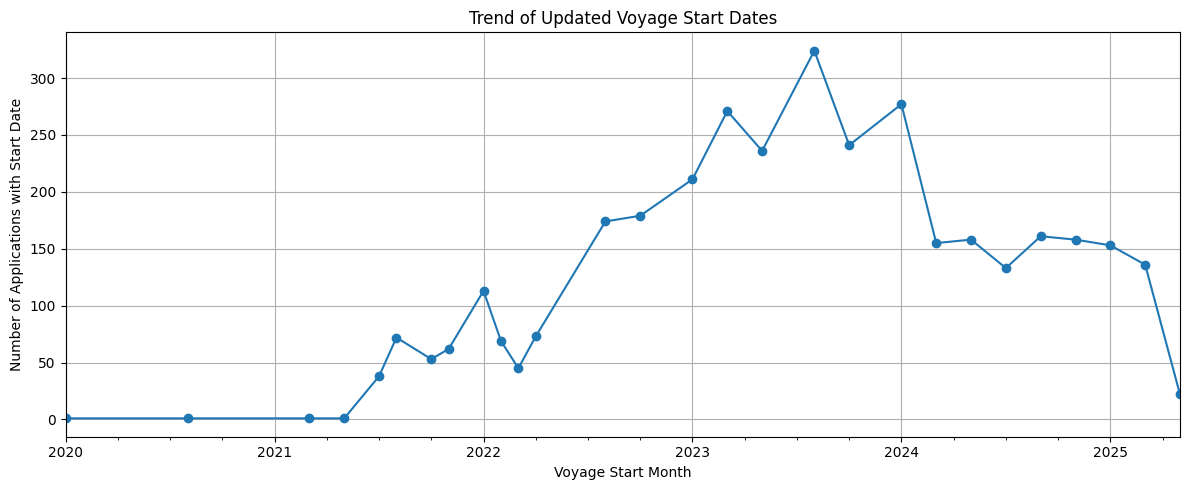

In [91]:
import warnings
warnings.filterwarnings('ignore')
# Convert 'Updated Voyage Start Date' to datetime
df_expanded_applications['Updated Voyage Start Date'] = pd.to_datetime(df_expanded_applications['Updated Voyage Start Date'], errors='coerce')

# Drop rows with no start date
voyage_start_df = df_expanded_applications.dropna(subset=['Updated Voyage Start Date'])

# Group by month-year for trend
voyage_start_df['Voyage Start Month'] = voyage_start_df['Updated Voyage Start Date'].dt.to_period('M')

# Count of voyages starting each month
voyage_start_trend = (
    voyage_start_df.groupby('Voyage Start Month')
    .size()
    .sort_index()
)

# Plot
plt.figure(figsize=(12, 5))
voyage_start_trend.plot(marker='o')
plt.title("Trend of Updated Voyage Start Dates")
plt.xlabel("Voyage Start Month")
plt.ylabel("Number of Applications with Start Date")
# add a legend for goal and role 
plt.grid(True)
plt.tight_layout()
plt.show()

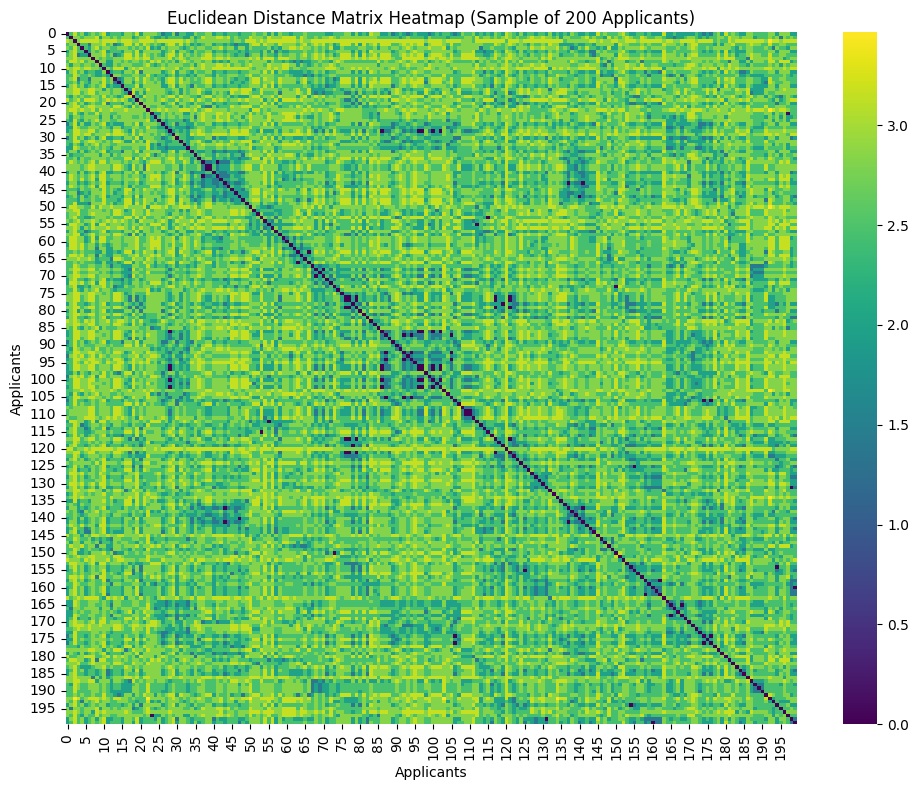


Cross-Validation Accuracy Scores: [nan nan nan nan nan]
Mean CV Accuracy: nan

Classification Report (Dev):
              precision    recall  f1-score   support

           0       0.72      0.90      0.80      1373
           1       0.59      0.28      0.38       683

    accuracy                           0.70      2056
   macro avg       0.65      0.59      0.59      2056
weighted avg       0.67      0.70      0.66      2056


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.72      0.89      0.79      1374
           1       0.57      0.29      0.38       683

    accuracy                           0.69      2057
   macro avg       0.64      0.59      0.59      2057
weighted avg       0.67      0.69      0.66      2057



In [92]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from scipy.spatial import distance
from sklearn.decomposition import PCA


# Feature Engineering
df_expanded_applications['Updated Voyage Start Date'] = pd.to_datetime(df_expanded_applications['Updated Voyage Start Date'], errors='coerce')
df_expanded_applications['Will Join Voyage'] = df_expanded_applications['Updated Voyage Start Date'].notna().astype(int)

# Filter relevant features
features = [
    'Voyage Role', 'Gender', 'Goal', 'Source',
    'Subscription Status', 'Application Age in Days', 'Application Day-of-Week'
]
df_expanded_applications = df_expanded_applications[features + ['Will Join Voyage']].dropna()

X = df_expanded_applications[features]
y = df_expanded_applications['Will Join Voyage']

# Preprocessing
categorical = ['Voyage Role', 'Gender', 'Goal', 'Source', 'Subscription Status', 'Application Day-of-Week']
numerical = ['Application Age in Days']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', StandardScaler(), numerical)
])

# Fit preprocessing on full dataset for clustering insight
X_processed = preprocessor.fit_transform(X)

# Compute distance matrix for clustering-based grouping
sample_size = 200
X_sample = X_processed[:sample_size].toarray() if hasattr(X_processed[:sample_size], 'toarray') else X_processed[:sample_size]
distance_matrix = distance.cdist(X_sample, X_sample, metric='euclidean')

# Heatmap of distance matrix
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix, cmap='viridis')
plt.title("Euclidean Distance Matrix Heatmap (Sample of 200 Applicants)")
plt.xlabel("Applicants")
plt.ylabel("Applicants")
plt.tight_layout()
plt.show()

# Split dataset: Train (60%), Dev (20%), Test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_dev, y_train, y_dev = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

# Ridge Regression with Cross-Validation
ridge = RidgeCV(alphas=np.logspace(-3, 3, 7), cv=5)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('ridge', ridge)
])

# Cross-validation on training set
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print("\nCross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Train final model on Train set
model.fit(X_train, y_train)

# Evaluate on Dev set
y_dev_pred = model.predict(X_dev) > 0.5
print("\nClassification Report (Dev):")
print(classification_report(y_dev, y_dev_pred))

# Evaluate on Test set
y_test_pred = model.predict(X_test) > 0.5
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))



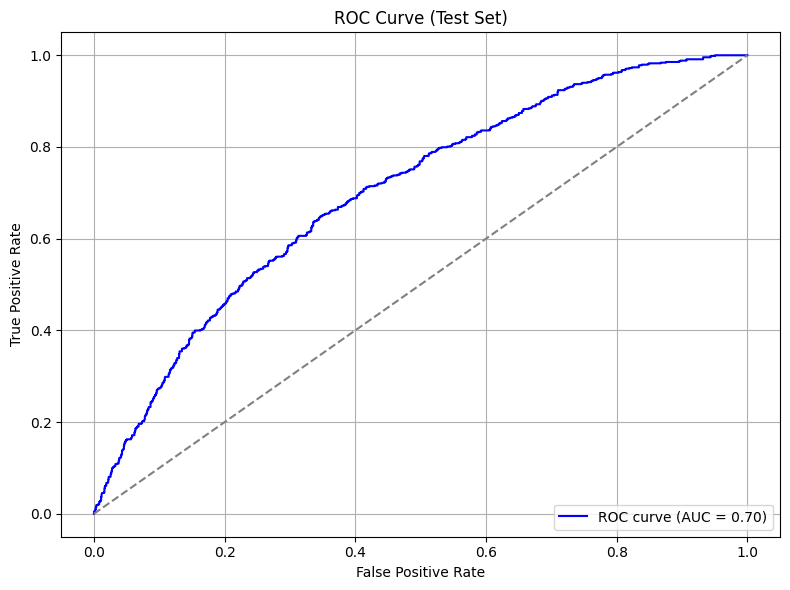

In [93]:
# Evaluate on Test set
y_test_scores = model.predict(X_test)
y_test_pred = y_test_scores > 0.5


# ROC Curve for Test set
fpr, tpr, _ = roc_curve(y_test, y_test_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

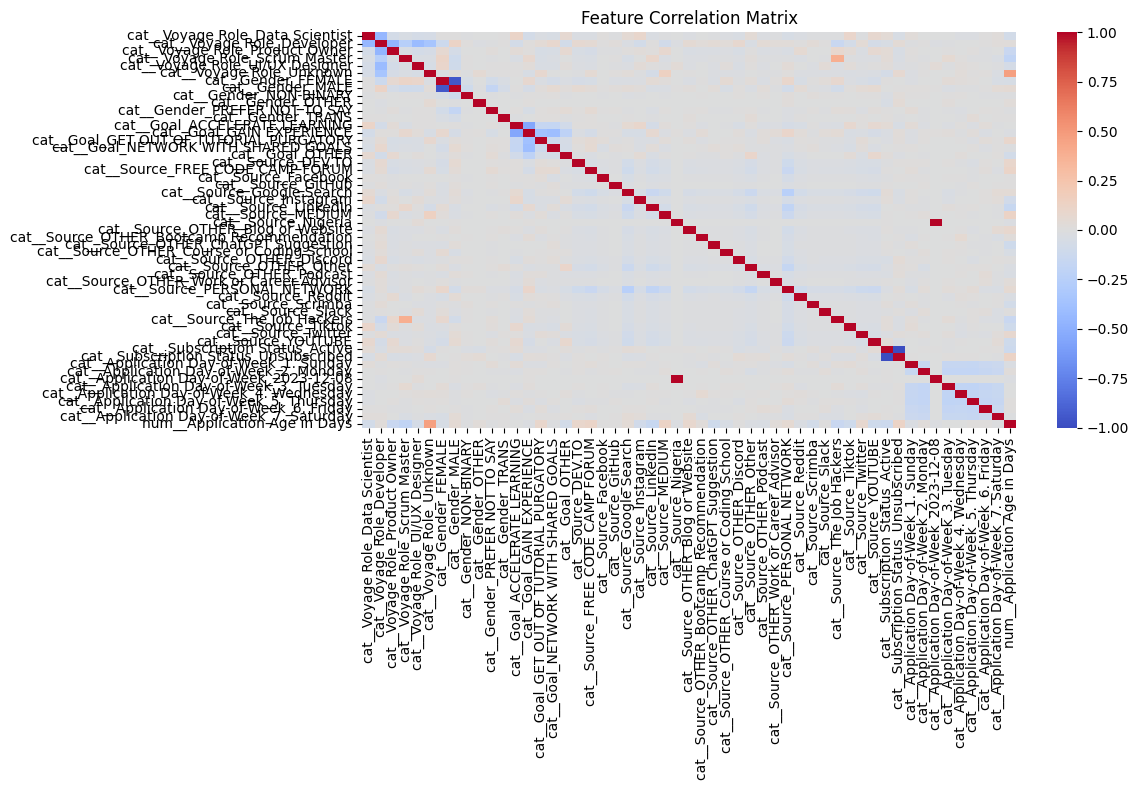

In [94]:

# Feature Engineering
# df_expanded_applications['Updated Voyage Start Date'] = pd.to_datetime(df_expanded_applications['Updated Voyage Start Date'], errors='coerce')
# df_expanded_applications['Will Join Voyage'] = df_expanded_applications['Updated Voyage Start Date'].notna().astype(int)

# Select relevant features
features = [
    'Voyage Role', 'Gender', 'Goal', 'Source',
    'Subscription Status', 'Application Age in Days', 'Application Day-of-Week'
]
df = df_expanded_applications[features + ['Will Join Voyage']].dropna()

X = df[features]
y = df['Will Join Voyage']

# Preprocessing
categorical = ['Voyage Role', 'Gender', 'Goal', 'Source', 'Subscription Status', 'Application Day-of-Week']
numerical = ['Application Age in Days']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', StandardScaler(), numerical)
])

# Fit and transform features
X_processed = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

# Convert processed features to a DataFrame
X_processed_df = pd.DataFrame(X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed, columns=feature_names)

# Compute correlation matrix
correlation_matrix = X_processed_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, xticklabels=feature_names, yticklabels=feature_names)
plt.title("Feature Correlation Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Optimal number of PCA components for 95% variance: 26


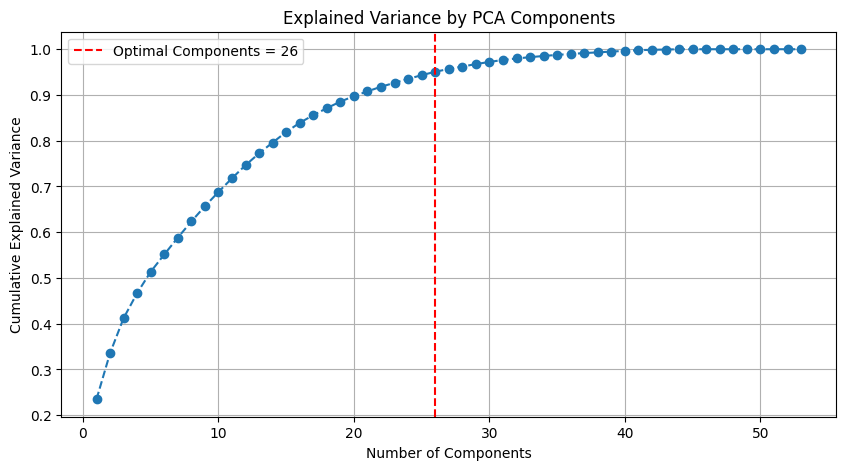


Cross-Validation Accuracy Scores: [nan nan nan nan nan]
Mean CV Accuracy: nan

Classification Report (Dev):
              precision    recall  f1-score   support

           0       0.68      0.93      0.79      1373
           1       0.50      0.14      0.21       683

    accuracy                           0.67      2056
   macro avg       0.59      0.53      0.50      2056
weighted avg       0.62      0.67      0.60      2056


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.70      0.93      0.80      1374
           1       0.58      0.18      0.28       683

    accuracy                           0.69      2057
   macro avg       0.64      0.56      0.54      2057
weighted avg       0.66      0.69      0.63      2057



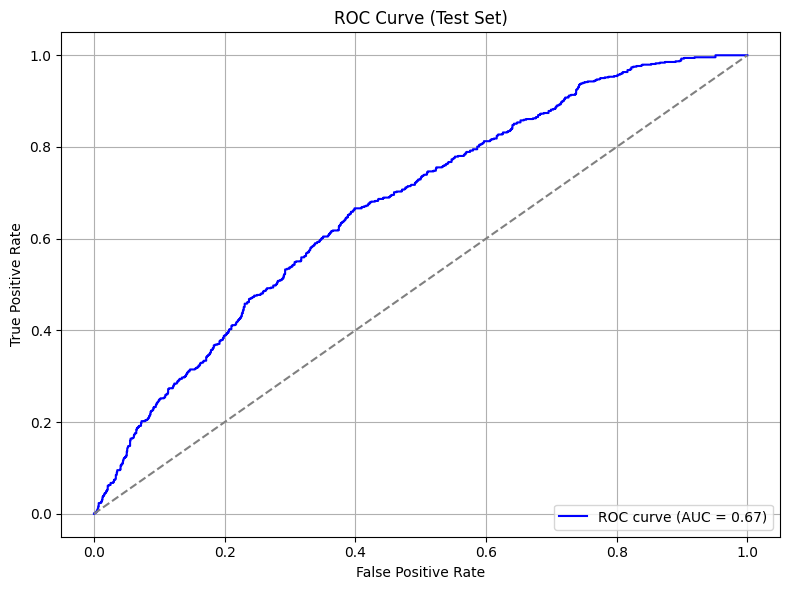

In [95]:
df = df_expanded_applications[features + ['Will Join Voyage']].dropna()

X = df[features]
y = df['Will Join Voyage']

# Preprocessing
categorical = ['Voyage Role', 'Gender', 'Goal', 'Source', 'Subscription Status', 'Application Day-of-Week']
numerical = ['Application Age in Days']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
    ('num', StandardScaler(), numerical)
])

# Fit preprocessing on full dataset for clustering insight
X_processed = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()

# Apply PCA for dynamic component selection
pca = PCA()
X_pca = pca.fit_transform(X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed)

# Determine number of components for 95% explained variance
explained_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_optimal = np.argmax(explained_variance >= 0.95) + 1

print(f"Optimal number of PCA components for 95% variance: {n_components_optimal}")

# Apply PCA with optimal components
pca_optimal = PCA(n_components=n_components_optimal)
X_pca_optimal = pca_optimal.fit_transform(X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed)

# Explained variance plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.axvline(n_components_optimal, color='r', linestyle='--', label=f'Optimal Components = {n_components_optimal}')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.legend()
plt.grid(True)
plt.show()

# Split dataset: Train (60%), Dev (20%), Test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X_pca_optimal, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_dev, y_train, y_dev = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

# Ridge Regression with Cross-Validation
ridge = RidgeCV(alphas=np.logspace(-3, 3, 7), cv=5)
model = Pipeline(steps=[
    ('ridge', ridge)
])

# Cross-validation on training set
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print("\nCross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Train final model on Train set
model.fit(X_train, y_train)

# Evaluate on Dev set
y_dev_scores = model.predict(X_dev)
y_dev_pred = y_dev_scores > 0.5
print("\nClassification Report (Dev):")
print(classification_report(y_dev, y_dev_pred))

# Evaluate on Test set
y_test_scores = model.predict(X_test)
y_test_pred = y_test_scores > 0.5
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

# ROC Curve for Test set
fpr, tpr, _ = roc_curve(y_test, y_test_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()



Cross-Validation Accuracy Scores: [0.68638574 0.69529984 0.70340357 0.67883212 0.67802109]
Mean CV Accuracy: 0.6883884689146788

Classification Report (Dev):
              precision    recall  f1-score   support

           0       0.71      0.90      0.80      1373
           1       0.58      0.27      0.37       683

    accuracy                           0.69      2056
   macro avg       0.65      0.59      0.58      2056
weighted avg       0.67      0.69      0.65      2056


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.72      0.90      0.80      1374
           1       0.59      0.30      0.40       683

    accuracy                           0.70      2057
   macro avg       0.66      0.60      0.60      2057
weighted avg       0.68      0.70      0.67      2057



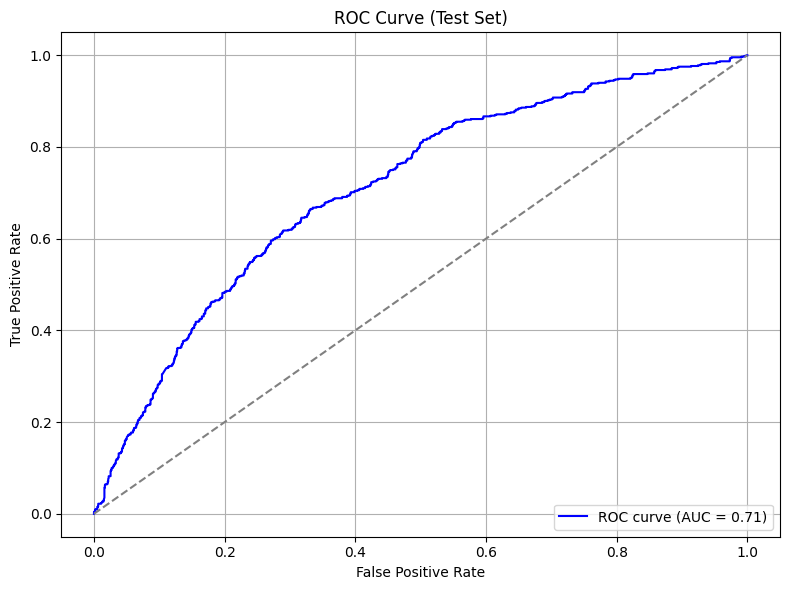

In [69]:
from sklearn.svm import SVC
# Support Vector Machine (SVM) with Cross-Validation
svm = SVC(kernel='rbf', probability=True)
model = Pipeline(steps=[
    ('svm', svm)
])

# Cross-validation on training set
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print("\nCross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Train final model on Train set
model.fit(X_train, y_train)

# Evaluate on Dev set
y_dev_scores = model.predict_proba(X_dev)[:, 1]
y_dev_pred = y_dev_scores > 0.5
print("\nClassification Report (Dev):")
print(classification_report(y_dev, y_dev_pred))

# Evaluate on Test set
y_test_scores = model.predict_proba(X_test)[:, 1]
y_test_pred = y_test_scores > 0.5
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

# ROC Curve for Test set
fpr, tpr, _ = roc_curve(y_test, y_test_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

Optimal number of PCA components for 95% variance: 26


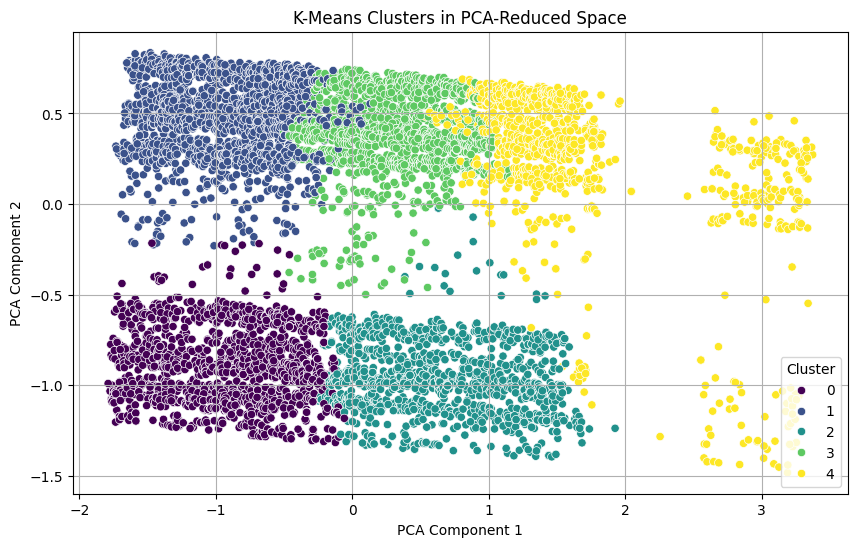


Cross-Validation Accuracy Scores: [0.68638574 0.69529984 0.70340357 0.67883212 0.67802109]
Mean CV Accuracy: 0.6883884689146788

Classification Report (Dev):
              precision    recall  f1-score   support

           0       0.71      0.90      0.80      1373
           1       0.58      0.28      0.38       683

    accuracy                           0.69      2056
   macro avg       0.65      0.59      0.59      2056
weighted avg       0.67      0.69      0.66      2056


Classification Report (Test):
              precision    recall  f1-score   support

           0       0.72      0.89      0.80      1374
           1       0.59      0.31      0.41       683

    accuracy                           0.70      2057
   macro avg       0.65      0.60      0.60      2057
weighted avg       0.68      0.70      0.67      2057



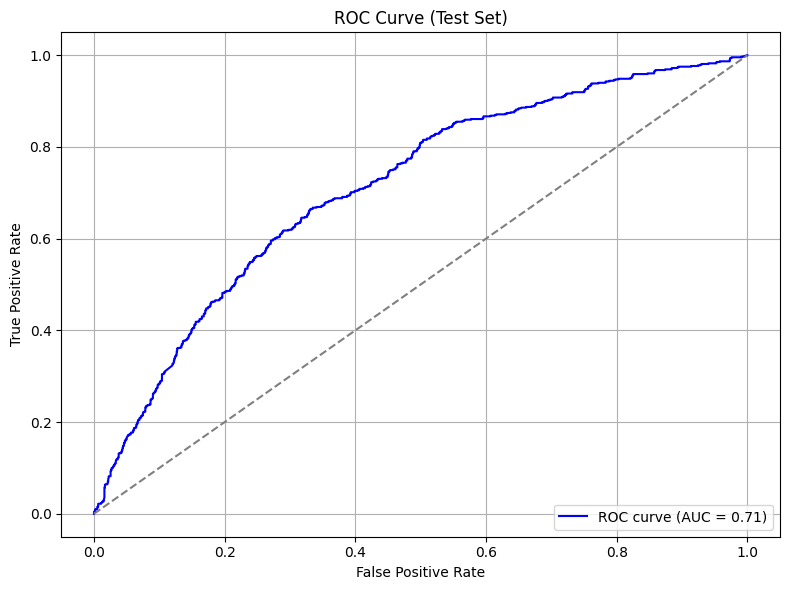

In [70]:
from sklearn.cluster import KMeans

# K-Means Clustering to find potential categories before PCA
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_processed)
df['Cluster'] = kmeans_labels

# Apply PCA for dynamic component selection
pca = PCA()
X_pca = pca.fit_transform(X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed)

# Determine number of components for 95% explained variance
explained_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_optimal = np.argmax(explained_variance >= 0.95) + 1

print(f"Optimal number of PCA components for 95% variance: {n_components_optimal}")

# Apply PCA with optimal components
pca_optimal = PCA(n_components=n_components_optimal)
X_pca_optimal = pca_optimal.fit_transform(X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed)

# Visualizing Clusters in PCA Space
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca_optimal[:, 0], y=X_pca_optimal[:, 1], hue=kmeans_labels, palette='viridis')
plt.title("K-Means Clusters in PCA-Reduced Space")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

# Split dataset: Train (60%), Dev (20%), Test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X_pca_optimal, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_dev, y_train, y_dev = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

# Support Vector Machine (SVM) with Cross-Validation
svm = SVC(kernel='rbf', probability=True)
model = Pipeline(steps=[
    ('svm', svm)
])

# Cross-validation on training set
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print("\nCross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Train final model on Train set
model.fit(X_train, y_train)

# Evaluate on Dev set
y_dev_scores = model.predict_proba(X_dev)[:, 1]
y_dev_pred = y_dev_scores > 0.5
print("\nClassification Report (Dev):")
print(classification_report(y_dev, y_dev_pred))

# Evaluate on Test set
y_test_scores = model.predict_proba(X_test)[:, 1]
y_test_pred = y_test_scores > 0.5
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

# ROC Curve for Test set
fpr, tpr, _ = roc_curve(y_test, y_test_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

Optimal number of clusters: 2
Optimal number of PCA components for 95% variance: 26
Optimal number of selected features: 11
Selected features: ['cat__Source_Instagram', 'cat__Voyage Role_Developer', 'cat__Goal_ACCELERATE LEARNING', 'cat__Source_Tiktok', 'cat__Voyage Role_Data Scientist', 'cat__Gender_NON-BINARY', 'cat__Goal_GAIN EXPERIENCE', 'cat__Source_OTHER_Work or Career Advisor', 'cat__Source_PERSONAL NETWORK', 'cat__Source_Google Search', 'num__Application Age in Days']

Cross-Validation Accuracy Scores: [0.67585089 0.68314425 0.68395462 0.67153285 0.67964315]
Mean CV Accuracy: 0.6788251500799857

Classification Report (Dev):
              precision    recall  f1-score   support

           0       0.68      0.95      0.79      1373
           1       0.53      0.11      0.19       683

    accuracy                           0.67      2056
   macro avg       0.61      0.53      0.49      2056
weighted avg       0.63      0.67      0.59      2056


Classification Report (Test):
  

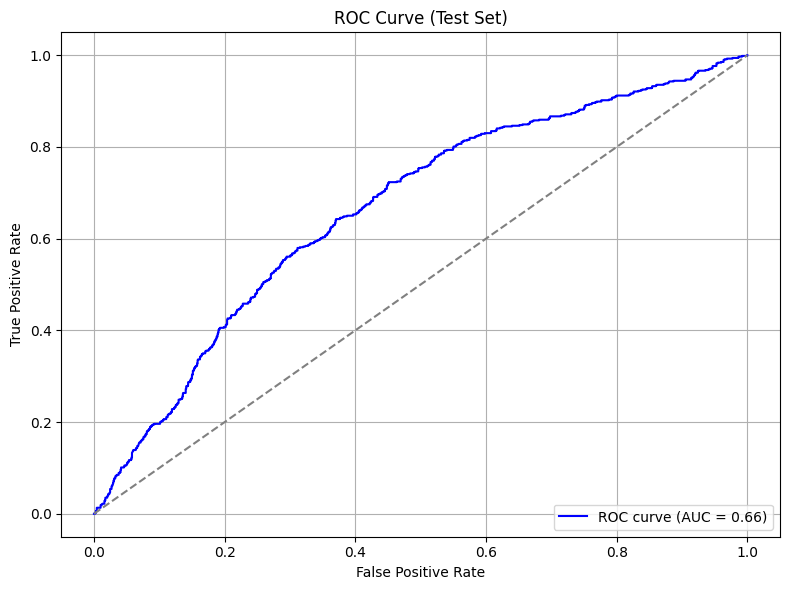

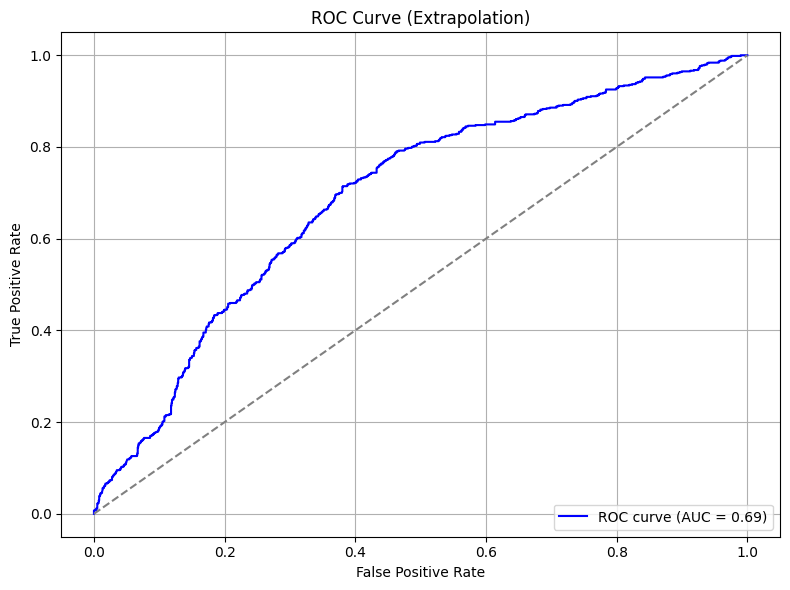

In [96]:
from sklearn.metrics import silhouette_score
# Determine the optimal number of clusters for K-Means using Silhouette Score
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_processed)
    silhouette_avg = silhouette_score(X_processed, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Select the best number of clusters dynamically
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters: {optimal_k}")

# Apply K-Means with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_processed)
df['Cluster'] = kmeans_labels

# Apply PCA for dynamic component selection
pca = PCA()
X_pca = pca.fit_transform(X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed)

# Determine number of components for 95% explained variance
explained_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_optimal = np.argmax(explained_variance >= 0.95) + 1

print(f"Optimal number of PCA components for 95% variance: {n_components_optimal}")

# Apply PCA with optimal components
pca_optimal = PCA(n_components=n_components_optimal)
X_pca_optimal = pca_optimal.fit_transform(X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed)

# Reverse transform to original feature space
X_reversed = pca_optimal.inverse_transform(X_pca_optimal)
X_reversed_df = pd.DataFrame(X_reversed, columns=feature_names)

# Compute correlation between reversed PCA components and target variable
X_reversed_df['Will Join Voyage'] = y.values
correlation_matrix = X_reversed_df.corr()

# Dynamically determine the optimal number of most correlated features
threshold = 0.1  # Minimum correlation threshold to include a feature
top_features = correlation_matrix['Will Join Voyage'].abs().sort_values(ascending=False)
top_features = top_features[top_features > threshold].index.tolist()
top_features.remove('Will Join Voyage')  # Remove the target variable itself
print("Optimal number of selected features:", len(top_features))
print("Selected features:", top_features)

# Keep only highly correlated features for final model
X_selected = X_reversed_df[top_features]

# Split dataset: Train (60%), Dev (20%), Test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X_selected, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_dev, y_train, y_dev = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

# Support Vector Machine (SVM) with Cross-Validation
svm = SVC(kernel='rbf', probability=True)
model = Pipeline(steps=[
    ('svm', svm)
])

# Cross-validation on training set
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print("\nCross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

# Train final model on Train set
model.fit(X_train, y_train)

# Evaluate on Dev set
y_dev_scores = model.predict_proba(X_dev)[:, 1]
y_dev_pred = y_dev_scores > 0.5
print("\nClassification Report (Dev):")
print(classification_report(y_dev, y_dev_pred))

# Evaluate on Test set
y_test_scores = model.predict_proba(X_test)[:, 1]
y_test_pred = y_test_scores > 0.5
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

# ROC Curve for Test set
fpr, tpr, _ = roc_curve(y_test, y_test_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# ROC Curve for Test set
fpr, tpr, _ = roc_curve(y_dev, y_dev_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Extrapolation)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

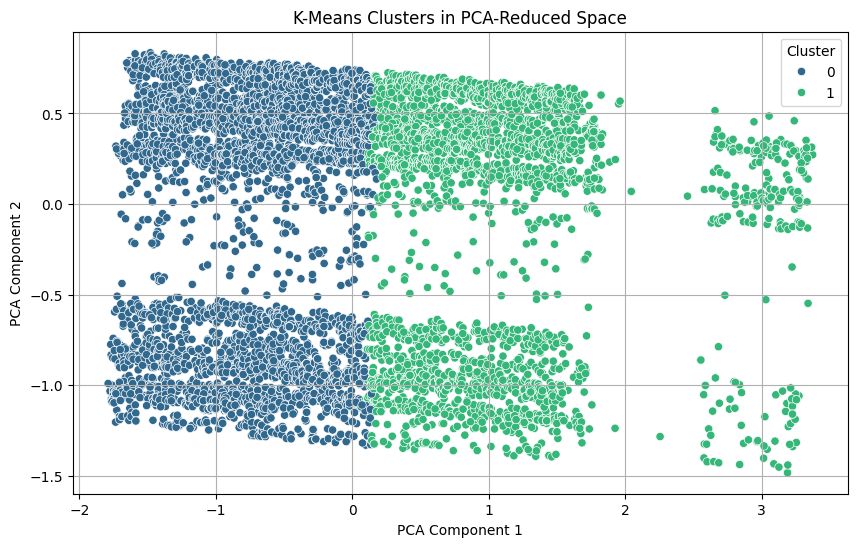

In [97]:
# Visualizing Clusters in PCA Space
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_pca_optimal[:, 0], y=X_pca_optimal[:, 1], hue=kmeans_labels, palette='viridis')
plt.title("K-Means Clusters in PCA-Reduced Space")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

In [99]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [100]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, InputLayer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

X_processed = preprocessor.fit_transform(X).toarray()

# Split dataset
X_temp, X_test, y_temp, y_test = train_test_split(X_processed, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_dev, y_train, y_dev = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

# MLP Model Definition
mlp_model = Sequential([
    InputLayer(input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

mlp_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# Training
mlp_model.fit(X_train, y_train, epochs=30, batch_size=32,
              validation_data=(X_dev, y_dev),
              callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
              verbose=1)

# Evaluate on all datasets
train_loss, train_acc = mlp_model.evaluate(X_train, y_train, verbose=0)
dev_loss, dev_acc = mlp_model.evaluate(X_dev, y_dev, verbose=0)
test_loss, test_acc = mlp_model.evaluate(X_test, y_test, verbose=0)

print(f"\nMLP Train Accuracy: {train_acc:.4f}")
print(f"MLP Dev Accuracy:   {dev_acc:.4f}")
print(f"MLP Test Accuracy:  {test_acc:.4f}")

# ROC Curve for MLP
y_test_scores = mlp_model.predict(X_test).ravel()
fpr, tpr, _ = roc_curve(y_test, y_test_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'MLP ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MLP ROC Curve (Test Set)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

Epoch 1/30


E0000 00:00:1742581284.008973   19267 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.1.0 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0000 00:00:1742581284.095824   19267 cuda_dnn.cc:522] Loaded runtime CuDNN library: 9.1.0 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
2025-03-21 19:21:24.109243: W tensorflow/core/framework/op_kernel.cc:1857] OP_REQUIRES failed at xla_ops.cc:591 : FAILED_PRECONDITION: DNN library initialization failed. Look at the er

FailedPreconditionError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main

  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code

  File "/home/razieh_ghahartars/.local/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/home/razieh_ghahartars/.local/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/home/razieh_ghahartars/.local/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/home/razieh_ghahartars/.local/lib/python3.10/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/usr/lib/python3.10/asyncio/base_events.py", line 603, in run_forever

  File "/usr/lib/python3.10/asyncio/base_events.py", line 1909, in _run_once

  File "/usr/lib/python3.10/asyncio/events.py", line 80, in _run

  File "/home/razieh_ghahartars/.local